# Task 2: Credit Risk Prediction

## Introduction

This notebook is part of my Data Science & Analytics Internship at DevelopersHub Corporation. The objective of this task is to build a machine learning model that predicts whether a loan applicant is likely to repay their loan or default, based on personal and financial information.

## Problem Statement

I am working with the Loan Prediction Dataset from Kaggle. It contains 614 loan applications with 13 columns including applicant income, loan amount, credit history, education, and employment status. The target variable is Loan_Status, whether a loan was approved or not. The goal is to clean the data, explore patterns through visualization, train two classification models, and evaluate their performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# splits data into training and testing sets
from sklearn.model_selection import train_test_split

# imports Logistic Regression model for classification
from sklearn.linear_model import LogisticRegression

# imports Decision Tree model for classification
from sklearn.tree import DecisionTreeClassifier

# imports evaluation metrics to assess model performance
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('train.csv')
print("Dataset Shape: ", df.shape)
print("First 5 rows of dataset")
df.head()

Dataset Shape:  (614, 13)
First 5 rows of dataset


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print("Data Types: ")
print(df.dtypes)
print("Total number of applicants (rows): ", df.shape[0])
print("Total number of features (cols): ", df.shape[1])

Data Types: 
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object
Total number of applicants (rows):  614
Total number of features (cols):  13


In [4]:
print("Missing values in each column: ")
df.isnull().sum()

Missing values in each column: 


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
for col in df.columns:
    print(col,df[col].nunique())

Loan_ID 614
Gender 2
Married 2
Dependents 4
Education 2
Self_Employed 2
ApplicantIncome 505
CoapplicantIncome 287
LoanAmount 203
Loan_Amount_Term 10
Credit_History 2
Property_Area 3
Loan_Status 2


In [6]:
# inspecting cols with less unique values.
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']:
    print(df[col].value_counts())
    print()

Gender
Male      489
Female    112
Name: count, dtype: int64

Married
Yes    398
No     213
Name: count, dtype: int64

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

Self_Employed
No     500
Yes     82
Name: count, dtype: int64

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64



In [7]:
# inspecting cols with many unique values

print('LoanAmount')
print('Mean: ', df['LoanAmount'].mean())
print('Median: ', df['LoanAmount'].median())

LoanAmount
Mean:  146.41216216216216
Median:  128.0


In [8]:
# fix text cols with most frequent value
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# fix number col with median
df['LoanAmount']= df['LoanAmount'].fillna(df['LoanAmount'].median())  

# verify everything is fixed
print("Missing values after cleaning: ")
df.isnull().sum()

Missing values after cleaning: 


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## Dataset Understanding and Description

The dataset contains 614 rows and 13 columns. Each row represents one loan applicant. The columns capture personal details, financial information, and the final loan decision.

The target variable is Loan_Status, Y means the loan was approved, N means it was not. After encoding, Y becomes 1 and N becomes 0.

Seven columns had missing values: Gender (13), Dependents (15), Self_Employed (32), LoanAmount (22), Loan_Amount_Term (14), Credit_History (50), and Married (3). Before deciding how to fill these gaps, I inspected each column individually. Text and binary columns were filled using mode, the most frequently occurring value. LoanAmount was filled using median instead of mean because its distribution is right-skewed, meaning a few very large loan requests pull the average upward unfairly.

In [9]:
# Dropping unnecessary columns

df.drop('Loan_ID', axis=1, inplace = True)
print("Remaining columns after dropping Loan_ID: ")
df.columns.tolist()

Remaining columns after dropping Loan_ID: 


['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

In [10]:
# Encode Text cols into numbers

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
text_columns = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']
for col in text_columns:
    df[col] = le.fit_transform(df[col])

print('Data after encoding')
df.head()

Data after encoding


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [11]:
# EDA 

sns.set(style='whitegrid')

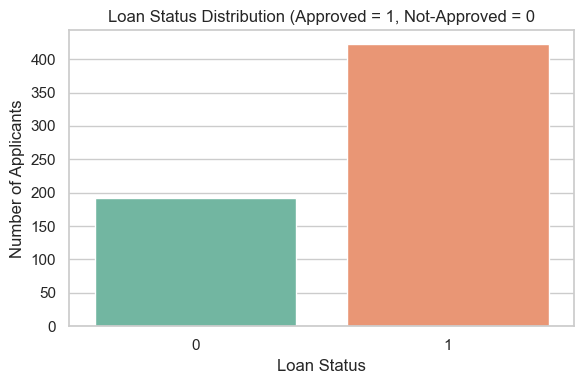

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data = df, palette='Set2')
plt.title("Loan Status Distribution (Approved = 1, Not-Approved = 0")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

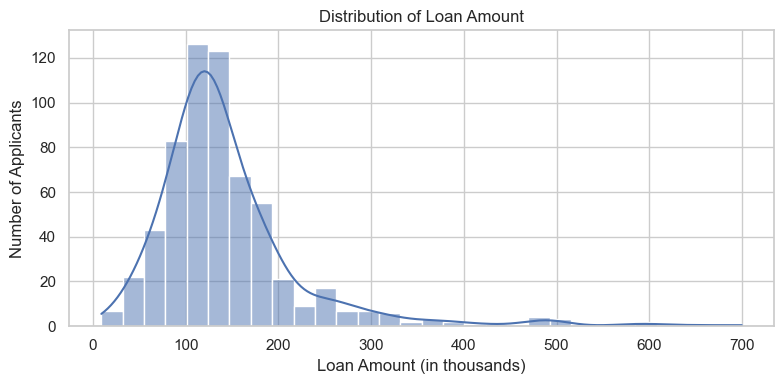

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(df['LoanAmount'], bins=30, kde=True)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount (in thousands)")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

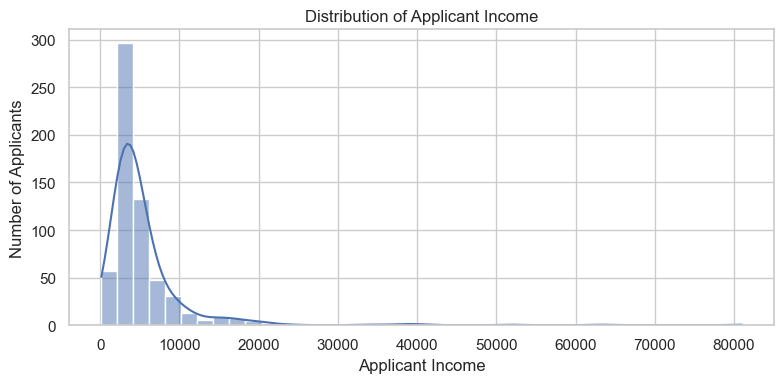

In [14]:
plt.figure(figsize=(8,4))
sns.histplot(df['ApplicantIncome'], bins=40, kde=True)
plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

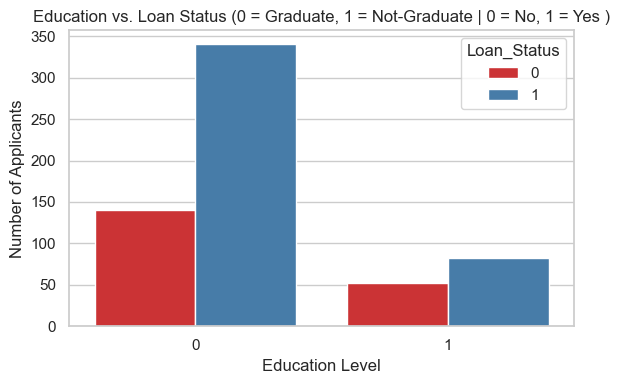

In [15]:
# PURPOSE: Does being a graduate improve chances of loan approval?

plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status',  data = df, palette='Set1')
plt.title("Education vs. Loan Status (0 = Graduate, 1 = Not-Graduate | 0 = No, 1 = Yes )")
plt.xlabel("Education Level")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

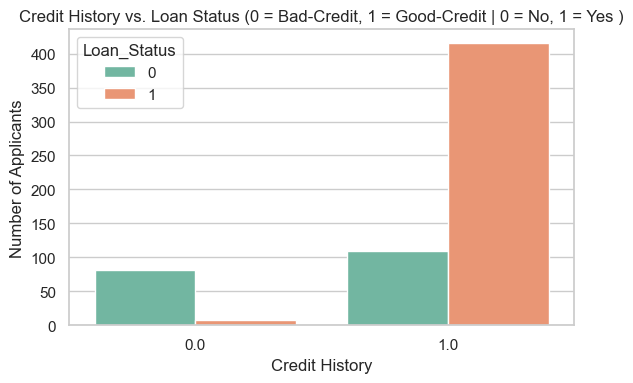

In [16]:
# PURPOSE: Is credit history the strongest predictor of loan approval?

plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status',  data = df, palette='Set2')
plt.title("Credit History vs. Loan Status (0 = Bad-Credit, 1 = Good-Credit | 0 = No, 1 = Yes )")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

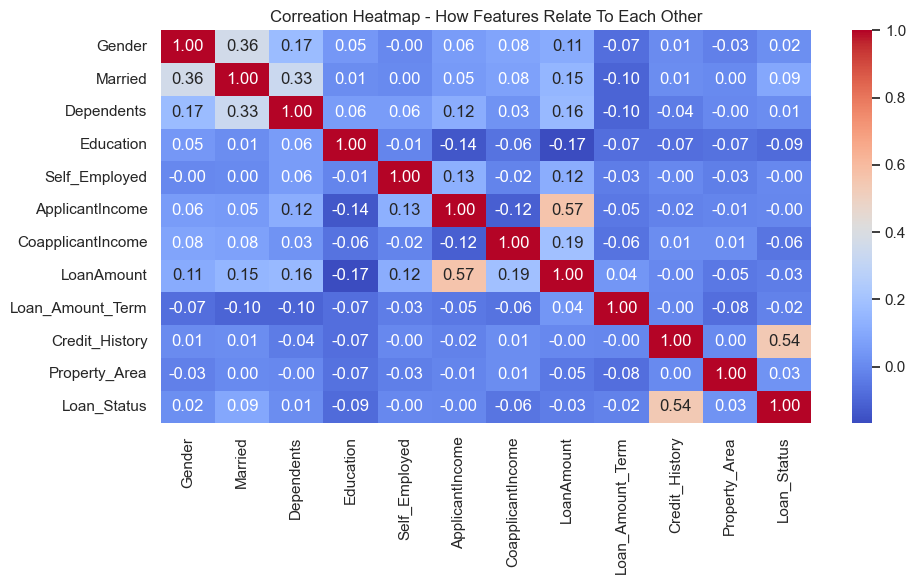

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correation Heatmap - How Features Relate To Each Other")
plt.tight_layout()
plt.show()

In [18]:
# Prepare data for machine learning

X = df.drop('Loan_Status', axis = 1)
Y = df['Loan_Status']
print("Features (x): ", X.shape)
print("Target (Y): ", Y.shape)
print("Feature Columns: ", X.columns.tolist())

Features (x):  (614, 11)
Target (Y):  (614,)
Feature Columns:  ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [19]:
# Splitting data into training and testing sets

X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y,
    test_size = 0.2,
    random_state = 5
)
print("Training Set Size: ", X_train.shape)
print("Testing Set Size: ", X_test.shape)

Training Set Size:  (491, 11)
Testing Set Size:  (123, 11)


In [20]:
# Train model 1 - Logistic Regression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, Y_train)
print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [21]:
# Train Model 2- Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, Y_train)
print("Decision Tree Model trained successfully")

Decision Tree Model trained successfully


In [22]:
# make predictions on test data

lr_predictions = lr_model.predict(X_test)
dt_predictions = dt_model.predict(X_test)

# compare first 10 predictions vs. actually answers

print("Logistic Regression first 10 predictions: ", lr_predictions[:10])
print("Decision Tree first 10 predictions: ", dt_predictions[:10])
print("Actual first 10 values: ", list(Y_test[:10]))

# If predictions mostly match actual values, the model is working correctly

Logistic Regression first 10 predictions:  [1 1 1 1 1 1 1 1 1 1]
Decision Tree first 10 predictions:  [1 1 1 1 1 1 1 1 1 1]
Actual first 10 values:  [1, 0, 1, 1, 1, 0, 1, 1, 1, 1]


Accuracy: ,  79.67%
Confusion matrix (Raw Numbers): 
[[18 22]
 [ 3 80]]


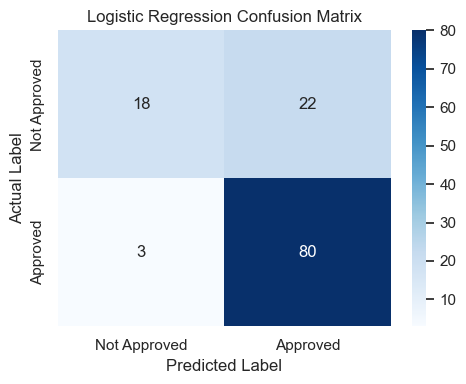

Classification Report: 
              precision    recall  f1-score   support

Not Approved       0.86      0.45      0.59        40
    Approved       0.78      0.96      0.86        83

    accuracy                           0.80       123
   macro avg       0.82      0.71      0.73       123
weighted avg       0.81      0.80      0.78       123



In [28]:
# Evaluate Logistic regression Model

lr_accuracy = accuracy_score(Y_test,lr_predictions)
print(f"Accuracy: , {lr_accuracy*100: .2f}%")
lr_cm = confusion_matrix(Y_test, lr_predictions)
print("Confusion matrix (Raw Numbers): ")
print(lr_cm)

plt.figure(figsize=(5,4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap = 'Blues', xticklabels=['Not Approved', 'Approved'], yticklabels=['Not Approved', 'Approved'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

print("Classification Report: ")
print(classification_report(Y_test, lr_predictions, target_names=['Not Approved', 'Approved']))        

Accuracy: ,  73.98%
Confusion matrix (Raw Numbers): 
[[22 18]
 [14 69]]


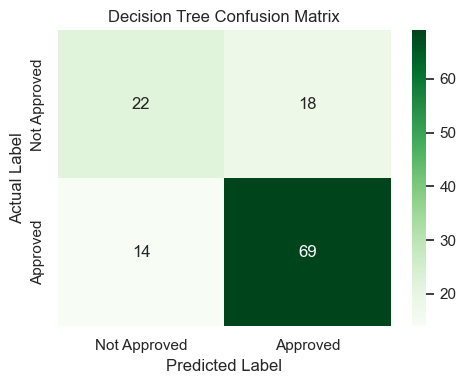

Classification Report: 
              precision    recall  f1-score   support

Not Approved       0.61      0.55      0.58        40
    Approved       0.79      0.83      0.81        83

    accuracy                           0.74       123
   macro avg       0.70      0.69      0.70       123
weighted avg       0.73      0.74      0.74       123



In [29]:
# Evaluate Decision Tree Model

dt_accuracy = accuracy_score(Y_test,dt_predictions)
print(f"Accuracy: , {dt_accuracy*100: .2f}%")
dt_cm = confusion_matrix(Y_test, dt_predictions)
print("Confusion matrix (Raw Numbers): ")
print(dt_cm)

plt.figure(figsize=(5,4))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap = 'Greens', xticklabels=['Not Approved', 'Approved'], yticklabels=['Not Approved', 'Approved'])
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

print("Classification Report: ")
print(classification_report(Y_test, dt_predictions, target_names=['Not Approved', 'Approved']))        

In [30]:
# Compare Both Models

print(f" Logistic Regression Accuracy: , {lr_accuracy*100: .2f}%")
print(f"Decision Tree Accuracy: , {dt_accuracy*100: .2f}%")
if lr_accuracy > dt_accuracy:
    better_model = "Logistic Regression"
else:
    better_model = "Decision Tree"
print("Better Performing Model: ", better_model)

 Logistic Regression Accuracy: ,  79.67%
Decision Tree Accuracy: ,  73.98%
Better Performing Model:  Logistic Regression


## Conclusion and Key Insights

The correlation heatmap revealed that Credit History has the strongest relationship with loan approval at 0.54. Every other feature scored below 0.10, confirming that credit history is by far the most influential factor in this dataset.

Visualizations confirmed this consistently:

1. The Credit History chart showed that almost no applicants with bad credit (0) received loan approval, while applicants with good credit (1) were approved at a very high rate.

2. The Loan Amount distribution showed a right-skew, most applicants requested between 50k and 200k, but a small number requested up to 700k. This confirmed the decision to use median rather than mean for filling missing values.

3. The Applicant Income distribution showed severe right-skew, the majority of applicants earn between 0 and 10,000, but a few earn up to 80,000, pulling the mean significantly higher than the median.

4. The Education chart showed that graduates had a higher approval rate than non-graduates.

Logistic Regression achieved 79.67% accuracy while Decision Tree achieved 73.98%, making Logistic Regression the better performing model on this dataset. However, both models struggled to correctly identify rejected loans. Logistic Regression only caught 18 out of 40 actual rejections. This is a direct consequence of class imbalance in the dataset, where approved loans outnumber rejected ones by more than two to one.

**Final Takeaway**
Credit history alone carries more predictive weight than all other features combined. A larger and more balanced dataset would be needed before using this model in a real lending environment.